# Blood Bag Safety Classification Using Cold Chain Telemetry

## Production Machine Learning Pipeline

### Project Overview

This project develops an end-to-end production-inspired machine learning pipeline for predicting whether a blood bag is safe for transfusion based on cold-chain telemetry data.

The objective is to assist healthcare providers by automatically identifying blood bags that may have experienced adverse storage or transportation conditions, thereby improving transfusion safety and reducing wastage.

The pipeline follows a production-oriented workflow consisting of:

- Data loading and validation
- Feature engineering
- Model training and evaluation
- Model selection
- Model persistence
- Simulated inference
- Data quality monitoring
- Drift detection
- Retraining strategy

Although implemented in a notebook, the workflow is modular and designed to closely resemble a deployable production ML system.

## Problem Definition

### Business Problem

Blood products must remain within safe environmental conditions throughout transportation and storage. Temperature excursions, excessive handling, humidity, and light exposure can reduce blood quality and compromise patient safety.

### Project Objective

The objective of this project is to build a production-ready machine learning pipeline capable of classifying whether a blood bag is safe or unsafe based on cold-chain telemetry data. The solution includes data preprocessing, feature engineering, model training, evaluation, model persistence, and deployment through a FastAPI inference service.

The final system enables automated safety prediction while following production machine learning best practices such as reusable preprocessing, model versioning, artifact persistence, and API-based inference.

### Machine Learning Objective

Develop a binary classification model that predicts whether a blood bag is safe or unsafe for transfusion using telemetry collected from IoT sensors.

### Inputs

- Temperature statistics
- Humidity
- Door openings
- Light exposure
- Handling stress
- Blood type
- Product type
- Route

### Output

- Safe (1)
- Unsafe (0)

### Success Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## 1. Import Libraries and Configure Project

This section imports all the required libraries and defines project-wide configurations such as dataset paths, model storage locations, and experiment settings. Centralizing these configurations improves reproducibility and makes future modifications easier.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib

print("✅ All libraries imported successfully!")
print("Scikit-learn version:", sklearn.__version__)

✅ All libraries imported successfully!
Scikit-learn version: 1.9.0


# 2. Data Loading and Initial Exploration

In this section, the cleaned blood cold-chain telemetry dataset is loaded into a Pandas DataFrame. Initial exploration is performed to understand the structure, verify the data types, inspect missing values, and ensure that the dataset is suitable for feature engineering and model training.

Understanding the dataset before preprocessing helps identify potential data quality issues and guides the selection of appropriate machine learning techniques.

In [4]:
df = pd.read_csv("../datasets/blood_cold_chain_cleaned.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (288000, 18)


,bag_id,timestamp,route,blood_type,product_type,temp_mean,temp_min,temp_max,temp_std,frac_temp_above_6,frac_temp_above_8,hum_mean,hum_std,door_count,light_mean_abs,accel_rms,handling_stress,health_index
0,BAG_0001,2024-01-11 00:00:00,Hospital_3,B-,RBC,3.500000,3.897717,4.023182,0.098555,0.035499,-0.002283,58.093670,3.140870,-0.014640,-2.558288,0.047550,0.442093,0.994176
1,BAG_0001,2024-01-11 01:00:00,Hospital_3,B-,RBC,3.500000,4.369670,4.446651,0.212670,0.054836,0.005992,60.000000,2.260903,0.062867,-1.911114,0.031802,0.445181,0.987408
2,BAG_0001,2024-01-11 02:00:00,Hospital_3,B-,RBC,4.339104,5.230218,5.548213,0.083685,0.061751,0.008715,60.000000,2.880617,-0.131211,-2.807997,0.042688,0.454198,0.980271
3,BAG_0001,2024-01-11 03:00:00,Hospital_3,B-,RBC,3.500000,4.163157,4.337382,0.120395,0.053772,0.009840,59.834760,2.848335,-0.053497,-1.915956,0.047537,0.457398,0.973170
4,BAG_0001,2024-01-11 04:00:00,Hospital_3,B-,RBC,3.500000,4.146593,4.162168,0.090862,0.051061,0.002331,57.434017,2.831188,-0.097074,-2.945096,0.047115,0.578019,0.966543


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   bag_id             288000 non-null  str    
 1   timestamp          288000 non-null  str    
 2   route              288000 non-null  str    
 3   blood_type         288000 non-null  str    
 4   product_type       288000 non-null  str    
 5   temp_mean          288000 non-null  float64
 6   temp_min           288000 non-null  float64
 7   temp_max           288000 non-null  float64
 8   temp_std           288000 non-null  float64
 9   frac_temp_above_6  288000 non-null  float64
 10  frac_temp_above_8  288000 non-null  float64
 11  hum_mean           288000 non-null  float64
 12  hum_std            288000 non-null  float64
 13  door_count         288000 non-null  float64
 14  light_mean_abs     288000 non-null  float64
 15  accel_rms          288000 non-null  float64
 16  handling_stre

### Data Load Observations

The dataset contains 288,000 records and 18 attributes describing the environmental conditions experienced by blood bags during transportation and storage.

The dataset consists of a combination of numerical telemetry features and categorical metadata such as blood type, product type, and transportation route.

No duplicate records were identified during validation. Any missing values detected in subsequent analysis will be handled before feature engineering.

Overall, the dataset is suitable for supervised machine learning after preprocessing and feature engineering.

# 3. Data Validation

Before training a machine learning model, it is important to verify the quality and consistency of the dataset. Data validation helps identify missing values, duplicate records, incorrect data types, and any anomalies that could negatively affect model performance.

This step ensures that the dataset is reliable and suitable for feature engineering and model training.

In [6]:
# Dataset dimensions

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 288,000
Number of Columns : 18


In [7]:
# Data types

df.dtypes

bag_id                   str
timestamp                str
route                    str
blood_type               str
product_type             str
temp_mean            float64
temp_min             float64
temp_max             float64
temp_std             float64
frac_temp_above_6    float64
frac_temp_above_8    float64
hum_mean             float64
hum_std              float64
door_count           float64
light_mean_abs       float64
accel_rms            float64
handling_stress      float64
health_index         float64
dtype: object

In [8]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing

bag_id               0
timestamp            0
handling_stress      0
accel_rms            0
light_mean_abs       0
door_count           0
hum_std              0
hum_mean             0
frac_temp_above_8    0
frac_temp_above_6    0
temp_std             0
temp_max             0
temp_min             0
temp_mean            0
product_type         0
blood_type           0
route                0
health_index         0
dtype: int64

In [9]:
# Duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [10]:
# Check unique values in categorical columns

categorical_columns = [
    "route",
    "blood_type",
    "product_type"
]

for column in categorical_columns:
    print("="*50)
    print(column.upper())
    print(df[column].value_counts())

ROUTE
route
Hospital_2    76800
Hospital_1    75840
Hospital_3    72000
Hospital_4    63360
Name: count, dtype: int64
BLOOD_TYPE
blood_type
O+     44160
A-     41280
A+     39360
AB-    37440
AB+    36480
B+     32640
B-     30720
O-     25920
Name: count, dtype: int64
PRODUCT_TYPE
product_type
RBC    288000
Name: count, dtype: int64


In [11]:
# Summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp_mean,288000.0,4.212943,1.040429,1.403712e+00,3.500000,3.612068,4.898884,11.511641
temp_min,288000.0,2.164361,1.243841,-6.131559e-01,1.245729,1.760677,3.108317,9.624692
temp_max,288000.0,4.894400,0.775938,2.055640e+00,4.422536,4.865654,5.292504,11.035945
temp_std,288000.0,0.164940,0.073226,-1.195692e-02,0.109705,0.163963,0.213302,0.379827
frac_temp_above_6,288000.0,-0.150181,0.171995,-4.079490e-01,-0.296754,-0.228825,0.006916,1.097066
frac_temp_above_8,288000.0,0.045879,0.050224,-5.642792e-02,0.020810,0.049914,0.070327,1.064442
hum_mean,288000.0,61.929367,6.184163,5.000000e+01,57.479605,60.000000,66.433686,84.690261
hum_std,288000.0,2.752188,0.589729,7.969679e-01,2.328489,2.758275,3.217644,4.203895
door_count,288000.0,0.723544,0.702016,-5.311730e-01,0.185639,0.647714,1.020573,6.214936
light_mean_abs,288000.0,-4.113438,5.869895,-1.423946e+01,-9.131061,-5.341520,-0.195023,23.638832


# 4. Exploratory Data Analysis (EDA)

Before developing the machine learning model, exploratory data analysis (EDA) is performed to understand the distribution of the variables, identify relationships between features, and detect any unusual patterns.

The insights obtained from this analysis will guide feature engineering, target variable creation, and model selection.

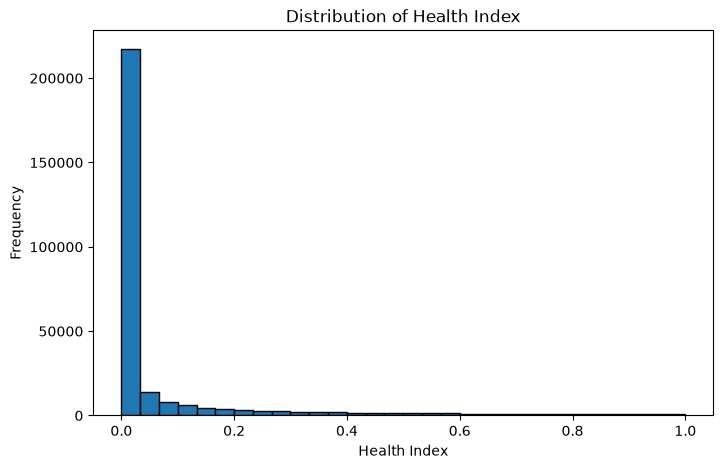

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["health_index"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Health Index")
plt.xlabel("Health Index")
plt.ylabel("Frequency")

plt.show()

### EDA Observations

- The Health Index exhibits a highly right-skewed distribution.
- Most observations are concentrated near zero, while only a small proportion of samples have higher health index values.
- The absence of a naturally balanced split indicates that the target variable requires careful threshold selection before converting it into a binary classification problem.
- The threshold for the `is_safe` target will be determined after analyzing the percentile distribution and resulting class balance.

In [13]:
df["health_index"].describe()

count    2.880000e+05
mean     7.382419e-02
std      1.789084e-01
min      2.910909e-09
25%      1.037536e-04
50%      1.556327e-03
75%      3.116248e-02
max      9.993902e-01
Name: health_index, dtype: float64

In [14]:
# Percentiles of the health index
df["health_index"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25    0.000104
0.50    0.001556
0.75    0.031162
0.90    0.258602
0.95    0.517120
0.99    0.875534
Name: health_index, dtype: float64

In [15]:
thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

for t in thresholds:
    safe = (df["health_index"] >= t).sum()
    unsafe = (df["health_index"] < t).sum()

    safe_pct = (safe / len(df)) * 100
    unsafe_pct = (unsafe / len(df)) * 100

    print(f"""
Threshold: {t:.2f}
Safe   : {safe:,} ({safe_pct:.2f}%)
Unsafe : {unsafe:,} ({unsafe_pct:.2f}%)
""")


Threshold: 0.05
Safe   : 62,228 (21.61%)
Unsafe : 225,772 (78.39%)


Threshold: 0.10
Safe   : 48,234 (16.75%)
Unsafe : 239,766 (83.25%)


Threshold: 0.20
Safe   : 33,981 (11.80%)
Unsafe : 254,019 (88.20%)


Threshold: 0.30
Safe   : 25,757 (8.94%)
Unsafe : 262,243 (91.06%)


Threshold: 0.40
Safe   : 19,863 (6.90%)
Unsafe : 268,137 (93.10%)


Threshold: 0.50
Safe   : 15,134 (5.25%)
Unsafe : 272,866 (94.75%)



### Target Variable Definition

The original dataset provides a continuous Health Index ranging from 0 to 1, where higher values indicate better blood bag quality.

For this project, the problem is formulated as a binary classification task to support operational decision-making in blood banks.

Exploratory Data Analysis showed that the Health Index distribution is highly right-skewed. Several threshold values were evaluated before selecting **0.05**. This threshold provides sufficient examples in both classes while preserving the distinction between healthier and degraded blood bags.

The binary target is defined as:

- Safe (1): Health Index ≥ 0.05
- Unsafe (0): Health Index < 0.05

In [16]:
# Create Binary Target Variable
THRESHOLD = 0.05

df["is_safe"] = (df["health_index"] >= THRESHOLD).astype(int)

print(df["is_safe"].value_counts())

print()

print(df["is_safe"].value_counts(normalize=True) * 100)

is_safe
0    225772
1     62228
Name: count, dtype: int64

is_safe
0    78.393056
1    21.606944
Name: proportion, dtype: float64


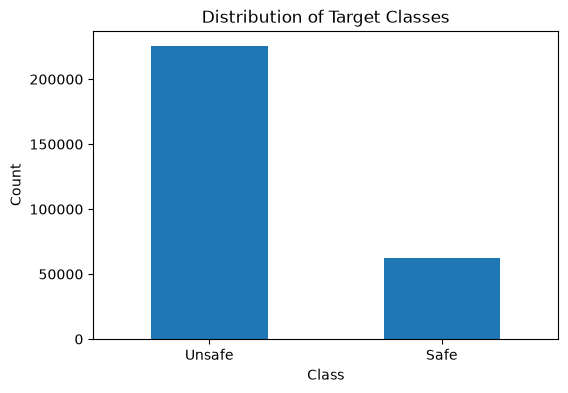

In [17]:
plt.figure(figsize=(6,4))

df["is_safe"].value_counts().plot(kind="bar")

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0, 1], ["Unsafe", "Safe"], rotation=0)

plt.show()

# 5. Feature Engineering

Feature engineering is the process of transforming raw telemetry data into more informative variables that improve a machine learning model's ability to identify meaningful patterns.

For blood cold-chain monitoring, raw sensor readings alone may not fully capture storage quality. Therefore, additional features are derived to represent temperature stability, environmental interactions, and handling conditions that directly influence blood bag safety.

These engineered features help the model better identify unsafe transportation or storage scenarios while improving predictive performance.

In [18]:
# Create Binary Target Variable

THRESHOLD = 0.05

df["is_safe"] = (df["health_index"] >= THRESHOLD).astype(int)

print(df["is_safe"].value_counts())

print("\nPercentage Distribution")

display(
    round(df["is_safe"].value_counts(normalize=True) * 100,2)
)

is_safe
0    225772
1     62228
Name: count, dtype: int64

Percentage Distribution


is_safe
0    78.39
1    21.61
Name: proportion, dtype: float64

In [19]:

# Feature Engineering

# 1. Temperature Range
df["temp_range"] = df["temp_max"] - df["temp_min"]

# 2. Temperature Coefficient of Variation
df["temp_cv"] = df["temp_std"] / (df["temp_mean"] + 1e-6)

# 3. Temperature Deviation from Ideal Storage (4°C)
df["temp_deviation"] = abs(df["temp_mean"] - 4)

# 4. Humidity per Temperature
df["humidity_per_temp"] = df["hum_mean"] / (df["temp_mean"] + 1e-6)

# 5. Handling Stress per Door Opening
df["handling_per_door"] = df["handling_stress"] / (df["door_count"] + 1)

In [20]:
engineered_features = [
    "temp_range",
    "temp_cv",
    "temp_deviation",
    "humidity_per_temp",
    "handling_per_door"
]

df[engineered_features].head()

,temp_range,temp_cv,temp_deviation,humidity_per_temp,handling_per_door
0,0.125465,0.028159,0.500000,16.598187,0.448662
1,0.076981,0.060763,0.500000,17.142852,0.418849
2,0.317995,0.019286,0.339104,13.827737,0.522795
3,0.174225,0.034399,0.500000,17.095641,0.483251
4,0.015574,0.025961,0.500000,16.409715,0.640163


In [21]:
df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temp_range,288000.0,2.730039,1.462322,-3.634242,1.542609,3.356347,3.839788,8.557834
temp_cv,288000.0,0.042329,0.023028,-0.002708,0.024090,0.039220,0.057535,0.220139
temp_deviation,288000.0,0.805720,0.691846,0.000015,0.500000,0.500000,1.032638,7.511641
humidity_per_temp,288000.0,15.395456,3.432206,5.033930,13.029256,15.669987,17.142852,49.340361
handling_per_door,288000.0,0.599189,0.233091,0.086710,0.438558,0.571673,0.723925,3.039449


### Feature Engineering Summary

Five additional features were created to better capture the physical conditions experienced by blood bags during transportation.

- **Temperature Range** captures fluctuations between the highest and lowest recorded temperatures.
- **Temperature Coefficient of Variation** measures relative temperature variability.
- **Temperature Deviation** quantifies how far the mean temperature deviates from the ideal storage temperature of 4°C.
- **Humidity per Temperature** captures the interaction between humidity and temperature.
- **Handling Stress per Door Opening** estimates handling intensity relative to storage access frequency.

These engineered features are generated during both model training and API inference to ensure consistency between the training and production environments, preventing training-serving skew.

### Preventing Target Leakage

The binary target (`is_safe`) was derived from the continuous `health_index` variable.

To prevent target leakage during model training, the original `health_index` feature will be removed from the input features before training the machine learning models.

This ensures that the model learns from telemetry and environmental variables rather than directly using the target information.

In [22]:
# Remove target leakage

df = df.drop(columns=["health_index"])

# 6. Data Preprocessing

Before training the machine learning models, the dataset is prepared by separating the input features from the target variable and encoding categorical attributes.

Columns such as `bag_id` and `timestamp` are excluded because they are identifiers rather than predictive features. Categorical variables are converted into numerical representations so they can be used by machine learning algorithms.

Label Encoding is applied to categorical variables because the selected Random Forest classifier requires numerical input features. The fitted encoders are saved as artifacts and reused during inference to ensure consistent encoding between training and deployment.

The feature engineering logic is encapsulated in a reusable preprocessing module, allowing the same transformations to be applied during both model training and API inference. This ensures consistency between training and production predictions.

In [23]:
# Target Variable
y = df["is_safe"]

# Feature Matrix
X = df.drop(columns=["is_safe"])

In [24]:
X = X.drop(columns=["bag_id", "timestamp"])

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "route",
    "blood_type",
    "product_type"
]

for column in categorical_columns:
    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    label_encoders[column] = encoder

In [26]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Feature Matrix Shape: (288000, 20)
Target Shape: (288000,)


,route,blood_type,product_type,temp_mean,temp_min,temp_max,temp_std,frac_temp_above_6,frac_temp_above_8,hum_mean,hum_std,door_count,light_mean_abs,accel_rms,handling_stress,temp_range,temp_cv,temp_deviation,humidity_per_temp,handling_per_door
0,2,5,0,3.500000,3.897717,4.023182,0.098555,0.035499,-0.002283,58.093670,3.140870,-0.014640,-2.558288,0.047550,0.442093,0.125465,0.028159,0.500000,16.598187,0.448662
1,2,5,0,3.500000,4.369670,4.446651,0.212670,0.054836,0.005992,60.000000,2.260903,0.062867,-1.911114,0.031802,0.445181,0.076981,0.060763,0.500000,17.142852,0.418849
2,2,5,0,4.339104,5.230218,5.548213,0.083685,0.061751,0.008715,60.000000,2.880617,-0.131211,-2.807997,0.042688,0.454198,0.317995,0.019286,0.339104,13.827737,0.522795
3,2,5,0,3.500000,4.163157,4.337382,0.120395,0.053772,0.009840,59.834760,2.848335,-0.053497,-1.915956,0.047537,0.457398,0.174225,0.034399,0.500000,17.095641,0.483251
4,2,5,0,3.500000,4.146593,4.162168,0.090862,0.051061,0.002331,57.434017,2.831188,-0.097074,-2.945096,0.047115,0.578019,0.015574,0.025961,0.500000,16.409715,0.640163


In [27]:
X.dtypes

route                  int64
blood_type             int64
product_type           int64
temp_mean            float64
temp_min             float64
temp_max             float64
temp_std             float64
frac_temp_above_6    float64
frac_temp_above_8    float64
hum_mean             float64
hum_std              float64
door_count           float64
light_mean_abs       float64
accel_rms            float64
handling_stress      float64
temp_range           float64
temp_cv              float64
temp_deviation       float64
humidity_per_temp    float64
handling_per_door    float64
dtype: object

### Observations

- The target variable was separated from the input features.
- Identifier columns (`bag_id` and `timestamp`) were removed because they do not contribute to prediction.
- All categorical variables were encoded into numerical values.
- The resulting feature matrix is suitable for machine learning model training.

# 7. Train-Test Split

To evaluate the performance of the machine learning models on unseen data, the dataset is divided into training and testing subsets.

The training set is used to learn the underlying patterns in the data, while the testing set is reserved for evaluating how well the trained models generalize to new observations.

A stratified split is used to preserve the proportion of Safe and Unsafe blood bags in both datasets.

In [28]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Class Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution")
print(y_test.value_counts(normalize=True))

Training Samples : 230400
Testing Samples  : 57600

Training Class Distribution
is_safe
0    0.783932
1    0.216068
Name: proportion, dtype: float64

Testing Class Distribution
is_safe
0    0.783924
1    0.216076
Name: proportion, dtype: float64


### Train-Test Split Summary

- The dataset was divided into 80% training data and 20% testing data.
- A stratified split was used to preserve the class distribution in both datasets.
- This approach ensures that both the training and testing sets contain representative proportions of Safe and Unsafe blood bags, reducing evaluation bias.

## 8. Handling Class Imbalance

The target variable contains approximately 22% Safe samples and 78% Unsafe samples.

To reduce bias towards the majority class, both Logistic Regression and Random Forest are trained using `class_weight="balanced"`, which automatically adjusts class weights during model training.

# 9. Baseline Model

A baseline model provides a reference point against which more advanced machine learning models can be evaluated.

Logistic Regression was selected as the baseline because it is computationally efficient, interpretable, and well suited for binary classification problems. Although it assumes a linear relationship between the features and the target variable, it provides a reliable benchmark for determining whether a more complex model offers a meaningful improvement.

Using a baseline model follows production machine learning best practices by ensuring that increased model complexity is justified through measurable performance gains rather than assumptions.

In [29]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

baseline_model.fit(X_train, y_train)

print("✅ Baseline model trained successfully.")

✅ Baseline model trained successfully.


/Users/rohit/Documents/BigData_BloodColdChainMonitoring/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
y_pred_baseline = baseline_model.predict(X_test)

y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1 Score": f1_score(y_test, y_pred_baseline),
    "ROC-AUC": roc_auc_score(y_test, y_prob_baseline)
}

baseline_metrics

{'Accuracy': 0.91765625,
 'Precision': 0.7411860479679379,
 'Recall': 0.9509882693234775,
 'F1 Score': 0.8330811191272215,
 'ROC-AUC': 0.9727242469681008}

In [32]:
baseline_results = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Metric", "Value"]
)

baseline_results

,Metric,Value
0,Accuracy,0.917656
1,Precision,0.741186
2,Recall,0.950988
3,F1 Score,0.833081
4,ROC-AUC,0.972724


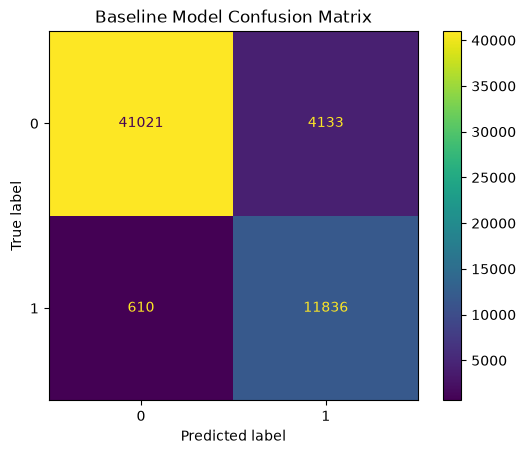

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test
)

plt.title("Baseline Model Confusion Matrix")

plt.show()

## Baseline Model Summary

The Logistic Regression model establishes the initial benchmark for evaluating predictive performance.

The obtained metrics provide a reference point for comparison with more advanced machine learning models. Any candidate model should demonstrate meaningful improvements while maintaining acceptable computational efficiency and reliable generalization performance.

This baseline serves as the minimum acceptable performance level. The candidate Random Forest model will be evaluated against this benchmark, and only if it demonstrates superior predictive performance and robustness will it be promoted to production.

# 10. Candidate Model

Random Forest was selected as the candidate production model because it can capture complex, non-linear relationships between telemetry features while remaining robust to noise and feature interactions.

Unlike Logistic Regression, Random Forest combines multiple decision trees, reducing overfitting through ensemble learning and generally providing stronger predictive performance for structured tabular datasets.

The candidate model will be compared against the baseline using multiple evaluation metrics before determining whether it should be promoted to production.

In [34]:
from sklearn.ensemble import RandomForestClassifier

candidate_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

candidate_model.fit(X_train, y_train)

print("✅ Candidate model trained successfully.")

✅ Candidate model trained successfully.


In [35]:
y_pred_candidate = candidate_model.predict(X_test)
y_prob_candidate = candidate_model.predict_proba(X_test)[:, 1]

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

candidate_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_candidate),
    "Precision": precision_score(y_test, y_pred_candidate),
    "Recall": recall_score(y_test, y_pred_candidate),
    "F1 Score": f1_score(y_test, y_pred_candidate),
    "ROC-AUC": roc_auc_score(y_test, y_prob_candidate)
}

candidate_results = pd.DataFrame(
    candidate_metrics.items(),
    columns=["Metric", "Value"]
)

candidate_results

,Metric,Value
0,Accuracy,0.941372
1,Precision,0.811158
2,Recall,0.949783
3,F1 Score,0.875014
4,ROC-AUC,0.986937


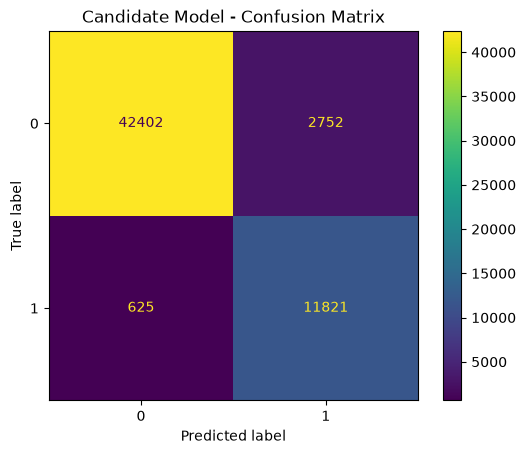

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    candidate_model,
    X_test,
    y_test
)

plt.title("Candidate Model - Confusion Matrix")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_candidate))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96     45154
           1       0.81      0.95      0.88     12446

    accuracy                           0.94     57600
   macro avg       0.90      0.94      0.92     57600
weighted avg       0.95      0.94      0.94     57600



In [39]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_prob_baseline)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_candidate),
        precision_score(y_test, y_pred_candidate),
        recall_score(y_test, y_pred_candidate),
        f1_score(y_test, y_pred_candidate),
        roc_auc_score(y_test, y_prob_candidate)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.917656,0.941372
1,Precision,0.741186,0.811158
2,Recall,0.950988,0.949783
3,F1 Score,0.833081,0.875014
4,ROC-AUC,0.972724,0.986937


## 11. Model Promotion Decision

Both the baseline Logistic Regression model and the candidate Random Forest model were evaluated using the same testing dataset.

The Random Forest classifier achieved the best overall performance across the evaluation metrics (Accuracy, Precision, Recall, F1-score, and ROC-AUC) and was therefore selected as the production model.

Based on these evaluation results, the Random Forest model was promoted to production, persisted using Joblib, and integrated into the FastAPI inference service for real-time prediction.

 ### Why Persist the Model?

The promoted production model is serialized using Joblib, allowing it to be loaded efficiently by the FastAPI inference service without requiring retraining.

In addition to the trained model, the fitted Label Encoders are also saved to ensure that categorical features are transformed consistently during both training and deployment.

# 12. Model Persistence

The selected production model is stored so it can be reused during inference without retraining. Evaluation metrics are also saved as artifacts to support reproducibility and future model comparisons.

In [46]:
from pathlib import Path
import joblib
import json

MODEL_DIR = Path("../models")
ARTIFACT_DIR = Path("../artifacts")

MODEL_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

In [49]:
joblib.dump(candidate_model, MODEL_DIR / "blood_bag_classifier.pkl")
print("✅ Model saved successfully.")

✅ Model saved successfully.


In [50]:
joblib.dump(label_encoders, ARTIFACT_DIR / "label_encoders.pkl")

print("✅ Label encoders saved successfully.")

✅ Label encoders saved successfully.


In [52]:
loaded_model = joblib.load("../models/blood_bag_classifier.pkl")
loaded_encoders = joblib.load("../artifacts/label_encoders.pkl")

print(type(loaded_model))
print(loaded_encoders.keys())

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
dict_keys(['route', 'blood_type', 'product_type'])


In [53]:
with open(ARTIFACT_DIR / "evaluation_metrics.json", "w") as f:
    json.dump(candidate_metrics, f, indent=4)

# 13. Simulated Inference

Once the production model has been persisted, it is loaded back into memory to simulate a real-world inference scenario.

Rather than retraining the model, a previously saved model artifact is used to generate predictions on new input data. This demonstrates how the trained model would operate within the deployed FastAPI application, ensuring consistency between training and production environments.

Successful inference confirms that the saved model and preprocessing artifacts can be reused reliably without requiring retraining.

In [54]:
loaded_model = joblib.load("../models/blood_bag_classifier.pkl")
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

label = "Safe" if prediction[0] == 1 else "Unsafe"

print(f"Predicted Class: {label}")

Predicted Class: Unsafe


### Inference Summary

The persisted model was successfully loaded and used to generate predictions on unseen data. This validates that the model artifacts are portable and can be integrated into a production inference service.

The same serialized model and preprocessing artifacts are reused by the FastAPI API, ensuring that predictions made during deployment are consistent with those obtained during model evaluation.

# 14. Future Improvements

Although the current system demonstrates an end-to-end production-inspired machine learning workflow, several enhancements could further improve its robustness and scalability.

Possible future improvements include:

- Implement automated data drift and concept drift detection to monitor changes in incoming telemetry data.
- Schedule periodic model retraining using newly collected blood cold-chain data to maintain predictive performance.
- Introduce model versioning and experiment tracking using tools such as MLflow.
- Containerize the inference service using Docker for easier deployment across different environments.
- Deploy the API to a cloud platform such as AWS, Azure, or Google Cloud Platform.
- Integrate a real-time monitoring dashboard to visualize prediction statistics, latency, and model health.
- Replace Label Encoding with more scalable encoding techniques if the number of categorical values increases significantly.
- Evaluate additional ensemble methods such as XGBoost or LightGBM for further performance improvements.

# 15. Conclusion

This project successfully demonstrates a complete production-inspired machine learning workflow for predicting blood bag safety using cold-chain telemetry data.

The workflow includes data validation, feature engineering, model training, evaluation, model promotion, artifact persistence, and deployment through a FastAPI inference service. The promoted Random Forest model was selected based on its superior predictive performance and integrated into a reusable inference pipeline.

Although simplified for educational purposes, the project follows several industry best practices, including reusable preprocessing, model serialization, API-based inference, reproducible workflows, and production-oriented system design. The solution provides a strong foundation for deploying machine learning models in real-world healthcare monitoring applications.